# Missing Person Search via FADING — Pipeline Suy diễn & Đánh giá (v3)

Chạy trên Kaggle Notebooks (GPU Tesla T4 / P100). Pipeline tối ưu cho độ phân giải chuẩn **512x512**, **50 bước DDIM**, can thiệp Dual-Attention (Self-Attention + Cross-Attention), khắc phục triệt để hiện tượng ám màu / tàn nhang bằng cách dùng UNet SD 1.5 nguyên bản, tối ưu Null-text Inversion không dừng sớm sai lệch và căn chỉnh ảnh đầu vào FFHQ chuẩn 512x512.


In [ ]:
# ===== KAGGLE: khong can mount gi ca - du lieu tu dong co san tai /kaggle/input =====
# In ra cau truc that de biet chinh xac ten thu muc dataset (phu thuoc ten ban dat
# luc tao dataset tren Kaggle, KHONG the biet truoc) - dung ket qua nay de dien vao
# cell "Khai bao duong dan" ben duoi.
import os

print("Cac dataset da gan vao notebook nay:")
for name in sorted(os.listdir("/kaggle/input")):
    print(f"  - {name}")

print("\nChi tiet 2 cap dau tien:")
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level <= 2:
        indent = "  " * level
        print(f"{indent}{os.path.basename(root) or root}/")
        if level == 2:
            for f in sorted(files)[:8]:
                print(f"{indent}  {f}")
            if len(files) > 8:
                print(f"{indent}  ... va {len(files)-8} file khac")


## Khai báo đường dẫn & Kiểm tra sẵn sàng trước khi chạy


In [ ]:
import os
import datetime
# ===== KAGGLE: SỬA đường dẫn dataset theo đúng tên dataset hiển thị ở cell trên =====
DATA_DIR = "/kaggle/input/datasets/menonkk/nckh-2025-2026"
# CKPT_DIR: Đường dẫn thư mục chứa checkpoint UNet đã fine-tune (512x512).
# Đặt CKPT_DIR = None nếu bạn muốn dùng trực tiếp UNet gốc của SD 1.5 (runwayml/stable-diffusion-v1-5).
CKPT_DIR = None  # Sửa thành đường dẫn checkpoint 512x512 của bạn, hoặc để None để dùng SD 1.5 gốc
OUTPUT_DIR = "/kaggle/working/FADING_output"
FFHQ_DIR = os.path.join(DATA_DIR, "ffhq_aging_150_samples/ffhq_aging_150_samples")
LABELS_CSV = os.path.join(FFHQ_DIR, "sampled_labels.csv")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("=" * 70)
print("KIỂM TRA SẴN SÀNG TRƯỚC KHI CHẠY PIPELINE")
print("=" * 70)
all_ok = True
def check(label, condition, detail=""):
    global all_ok
    status = "✅" if condition else "❌"
    if not condition:
        all_ok = False
    print(f"{status} {label}" + (f"  — {detail}" if detail else ""))
# 1. GPU
import torch
has_gpu = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if has_gpu else "không có"
check("GPU khả dụng", has_gpu, gpu_name if has_gpu else "Vào Runtime > Change runtime type > T4 GPU")
# 2. Thư mục dữ liệu gốc
check("DATA_DIR tồn tại", os.path.isdir(DATA_DIR), DATA_DIR)
# 3. Thư mục 140 ảnh Specialization & labels CSV
ffhq_ok = os.path.isdir(FFHQ_DIR)
check("Thư mục ffhq_aging_150_samples tồn tại", ffhq_ok)
if ffhq_ok:
    png_files = [f for f in os.listdir(FFHQ_DIR) if f.lower().endswith(".png")]
    check(f"Số ảnh .png trong đó (kỳ vọng ~140)", len(png_files) >= 100, f"đếm được {len(png_files)}")
    check("File sampled_labels.csv tồn tại", os.path.isfile(LABELS_CSV))
# 4. Ảnh test có trong 140 ảnh không
TEST_IMAGE_NAME = "01366.png"   # sửa nếu bạn chọn ảnh khác
if ffhq_ok:
    check(f"Ảnh test '{TEST_IMAGE_NAME}' có trong 140 ảnh", TEST_IMAGE_NAME in os.listdir(FFHQ_DIR))
# 5. Trạng thái checkpoint UNet
if CKPT_DIR is not None and os.path.isdir(CKPT_DIR):
    check(f"Sử dụng checkpoint UNet tùy chỉnh tại '{CKPT_DIR}'", True, "Checkpoint đã nạp")
else:
    check("Sử dụng UNet SD 1.5 nguyên bản", True, "runwayml/stable-diffusion-v1-5 (CKPT_DIR = None)")
print("=" * 70)
if all_ok:
    print("✅ TẤT CẢ ĐÃ SẴN SÀNG — có thể chạy tiếp các cell bên dưới.")
else:
    print("❌ CÒN THIẾU — xem lại các dòng ❌ ở trên trước khi chạy tiếp, tránh lỗi giữa chừng.")
print("=" * 70)


## Ghi log toàn bộ session ra file — để gửi cho Claude đọc

Từ đây trở đi, MỌI dòng `print()` (kể cả log của các cell sau) sẽ vừa hiện trên
màn hình như bình thường, vừa được ghi thêm vào 1 file `.txt` trong OUTPUT_DIR — không
cần copy tay từng đoạn log nữa, chỉ cần gửi file này.

Dùng chế độ **append** (nối thêm, không ghi đè) — nếu phiên Kaggle bị ngắt rồi mở
lại, chạy lại đúng cell này, log cũ vẫn còn nguyên, log mới nối tiếp vào sau.

In [ ]:
import sys
import datetime

LOG_FILE_PATH = os.path.join(OUTPUT_DIR, "full_session_log.txt")

# SUA (lan 2): "isinstance(sys.stdout, TeeLogger)" KHONG dang tin - moi lan cell
# nay chay lai, Python tao ra 1 class TeeLogger MOI (du code giong het), nen
# isinstance luon that bai, cu the boc them 1 lop moi -> boc chong vo han lan,
# gay loi de quy AttributeError (thay ro trong traceback: isatty() goi lap 4 lan).
#
# Cach sua dung tin cay: "boc tach" theo kieu duck-typing (kiem tra co thuoc tinh
# .terminal hay khong, khong quan tam class nao), lan xuong TAN GOC stdout that su
# (khong con thuoc tinh .terminal nua) - bat ke da bi boc chong bao nhieu lop truoc do.
_true_stdout = sys.stdout
while hasattr(_true_stdout, "terminal"):
    _true_stdout = _true_stdout.terminal

class TeeLogger:
    """Ghi dong thoi ra man hinh (terminal) VA ra file - khong mat cai nao ca."""
    def __init__(self, filepath, mode="a"):
        self.terminal = _true_stdout   # LUON tro thang ve stdout GOC, khong bao gio boc chong
        self.log_file = open(filepath, mode, encoding="utf-8")

    def write(self, message):
        self.terminal.write(message)
        self.log_file.write(message)
        self.log_file.flush()

    def flush(self):
        self.terminal.flush()
        self.log_file.flush()

    def isatty(self):
        return self.terminal.isatty()

    def __getattr__(self, name):
        return getattr(self.terminal, name)

sys.stdout = TeeLogger(LOG_FILE_PATH, mode="a")

print(f"\n{'='*70}")
print(f"===== BẮT ĐẦU / TIẾP TỤC GHI LOG — {datetime.datetime.now()} =====")
print(f"===== File log: {LOG_FILE_PATH} =====")
print(f"{'='*70}\n")


## Cài đặt thư viện

Colab đã có sẵn `torch`, `numpy`, `pandas`, `pillow`, `opencv-python`, `tqdm` — chỉ cần cài thêm phần chưa có.

In [6]:
# ===== Cai dat thu vien can thiet =====
!pip install -q diffusers transformers accelerate bitsandbytes insightface onnxruntime-gpu huggingface_hub
!pip install -q "git+https://github.com/WildChlamydia/MiVOLO.git"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.2/202.2 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 40.3 MB/s eta 0:00:00


## Cấu hình pipeline (hyperparameters) — tương đương `configs/config.yaml`

In [ ]:
config = {
    "base_model": {
        "pretrained_model_name_or_path": "runwayml/stable-diffusion-v1-5",
    },
    "inversion": {
        "num_inference_steps": 50,
        "guidance_scale": 4.0,           # Giảm từ 7.5 xuống 4.0 để chống cháy màu và mọc tàn nhang
        "num_inner_steps": 15,           # Tăng lên 15 để tối ưu hóa vector null-text triệt để
        "early_stop_epsilon": 1e-5,
        "image_size": 512,
    },
    "editing": {
        "guidance_scale": 4.0,           # Đồng bộ 4.0
        "attention_control_ratio": 0.8,
        "image_size": 512,
    },
    "embedding": {
        "model_name": "buffalo_l",
        "ctx_id": -1,
        "det_size": (256, 256),
    },
    "paths": {
        "ffhq_dir": FFHQ_DIR,
        "labels_csv": LABELS_CSV,
        "specialized_unet_ckpt": CKPT_DIR,
        "output_dir": os.path.join(OUTPUT_DIR, "edited_images"),
    },
}
config


## Hàm tiện ích dùng chung & Prompt Helpers (tương đương `src/utils/prompts.py`)


In [8]:
from typing import Dict
# Trung diem tung age_group trong sampled_labels.csv.
# Rieng nhom cuoi "70-120" LAY TAY = 80, khong dung trung diem toan hoc (se ra 95),
# vi paper FADING goc ghi ro: "For the oldest age group (70+), we translate to 80 years old".
AGE_GROUP_TO_AGE: Dict[str, int] = {
    "0-2": 1,
    "3-6": 4,
    "7-9": 8,
    "10-14": 12,
    "15-19": 17,
    "20-29": 24,
    "30-39": 34,
    "40-49": 44,
    "50-69": 59,
    "70-120": 80,
}
def age_group_to_age(age_group: str) -> int:
    """Quy doi 1 nhan age_group (vd "30-39") sang 1 con so tuoi dai dien (vd 34)."""
    return AGE_GROUP_TO_AGE[age_group]
def gender_to_word(gender: str, age: int) -> str:
    """Quy doi gender ("male"/"female") + tuoi sang tu mo ta gioi tinh dung trong prompt:
    woman/man cho nguoi lon (age >= 15), girl/boy neu age < 15."""
    is_female = gender.lower() == "female"
    if age < 15:
        return "girl" if is_female else "boy"
    return "woman" if is_female else "man"
def build_prompt_alpha(age: int, gender_word: str) -> str:
    """Build P_alpha = "photo of a {age} year old {gender_word}"."""
    return f"photo of a {age} year old {gender_word}"
def build_prompt_neutral(gender_word: str) -> str:
    """Build P_neutral = "photo of a {gender_word}" - prompt trung lap, khong chua tuoi."""
    return f"photo of a {gender_word}"
def build_prompt_tau(target_age: int, gender_word: str) -> str:
    """
    Enhanced Prompts: Bổ sung từ khóa mở rộng đặc trưng kết cấu da (texture) 
    tương ứng với từng phân khúc tuổi để Stable Diffusion định hình nếp nhăn/độ tuổi tốt hơn.
    """
    if target_age <= 20:
        return f"photo of a {target_age} year old {gender_word}, smooth young skin, clear complexion"
    elif target_age >= 60:
        return f"photo of a {target_age} year old {gender_word}, visible aging signs, deep wrinkles, crow's feet, mature skin"
    elif target_age >= 40:
        return f"photo of a {target_age} year old {gender_word}, subtle fine lines, mature skin"
    else:
        return f"photo of a {target_age} year old {gender_word}"


## Module 2 — Null-text Inversion (tương đương `src/fading/inversion.py`)

In [ ]:
from typing import Dict as _Dict, Optional, List, Tuple
import os
import torch
from torchvision import transforms
import torch.nn.functional as F
from torch.optim import Adam
from PIL import Image
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
NUM_DDIM_STEPS_DEFAULT = 50
GUIDANCE_SCALE_DEFAULT = 4.0
# Chi luu attention map cua layer co do phan giai <= 32x32 - giam VRAM, dung theo toi uu cua
# Prompt-to-Prompt goc (layer do phan giai thap mang nhieu ngu nghia hon).
MAX_ATTN_RESOLUTION = 32 * 32
class DualAttentionCapture:
    """
    Bắt đồng thời Self-Attention (attn1) và Cross-Attention (attn2)
    trong quá trình DDIM Inversion.
    """
    def __init__(self, unet: UNet2DConditionModel):
        self.unet = unet
        self._orig_processors = unet.attn_processors
        self.captured_self: _Dict[str, torch.Tensor] = {}
        self.captured_cross: _Dict[str, torch.Tensor] = {}
        self.enabled = False
    def _build_processor(self, name: str):
        capture = self
        is_cross = name.endswith("attn2.processor")
        class _CapturingProcessor:
            def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, **kwargs):
                query = attn.to_q(hidden_states)
                context = encoder_hidden_states if encoder_hidden_states is not None else hidden_states
                key = attn.to_k(context)
                value = attn.to_v(context)
                query = attn.head_to_batch_dim(query)
                key = attn.head_to_batch_dim(key)
                value = attn.head_to_batch_dim(value)
                attention_probs = attn.get_attention_scores(query, key, attention_mask)
                # Chỉ lưu attention map của các layer có số lượng spatial tokens <= 32x32
                if capture.enabled and attention_probs.shape[1] <= MAX_ATTN_RESOLUTION:
                    if is_cross:
                        capture.captured_cross[name] = attention_probs.detach().cpu()
                    else:
                        capture.captured_self[name] = attention_probs.detach().cpu()
                hidden_states = torch.bmm(attention_probs, value)
                hidden_states = attn.batch_to_head_dim(hidden_states)
                hidden_states = attn.to_out[0](hidden_states)
                hidden_states = attn.to_out[1](hidden_states)
                return hidden_states
        return _CapturingProcessor()
    def register(self) -> None:
        # Gắn processor vào toàn bộ các layer attention (cả attn1 và attn2)
        new_processors = {name: self._build_processor(name) for name in self.unet.attn_processors.keys()}
        self.unet.set_attn_processor(new_processors)
    def restore(self) -> None:
        self.unet.set_attn_processor(self._orig_processors)
    def capture_step(self, forward_fn):
        self.captured_self = {}
        self.captured_cross = {}
        self.enabled = True
        with torch.no_grad():
            result = forward_fn()
        self.enabled = False
        return dict(self.captured_self), dict(self.captured_cross), result
class NullTextInverter:
    def __init__(
        self,
        pretrained_model_name_or_path: str = "runwayml/stable-diffusion-v1-5",
        unet_checkpoint_dir: Optional[str] = None,
        device: str = "cuda",
        num_inference_steps: int = 50,         # Đưa về 50 bước chuẩn
        guidance_scale: float = 7.5,
        num_inner_steps: int = 10,
        early_stop_epsilon: float = 1e-5,
        image_size: int = 512,                 # Đưa lên 512x512
    ):
        self.pretrained_model_name_or_path = pretrained_model_name_or_path
        self.unet_checkpoint_dir = unet_checkpoint_dir
        self.device = device
        self.num_inference_steps = num_inference_steps
        self.guidance_scale = guidance_scale
        self.num_inner_steps = num_inner_steps
        self.early_stop_epsilon = early_stop_epsilon
        self.image_size = image_size
        self.vae = None
        self.unet = None
        self.text_encoder = None
        self.tokenizer = None
        self.scheduler = None
    def _load_models(self) -> None:
        model_id = self.pretrained_model_name_or_path
        self.vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae", torch_dtype=torch.float16)
        self.text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder", torch_dtype=torch.float16)
        self.tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
        if self.unet_checkpoint_dir and os.path.isdir(self.unet_checkpoint_dir):
            self.unet = UNet2DConditionModel.from_pretrained(self.unet_checkpoint_dir, torch_dtype=torch.float16)
        else:
            self.unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16)
        self.scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler")
        self.scheduler.set_timesteps(self.num_inference_steps)
        self.vae.to(self.device).eval().requires_grad_(False)
        self.text_encoder.to(self.device).eval().requires_grad_(False)
        self.unet.to(self.device).eval().requires_grad_(False)
    def _load_image_latent(self, image_path: str) -> torch.Tensor:
        transform = transforms.Compose([
            transforms.Resize((self.image_size, self.image_size), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
        image = Image.open(image_path).convert("RGB")
        image_t = transform(image).unsqueeze(0).to(self.device, dtype=torch.float16)
        with torch.no_grad():
            latent = self.vae.encode(image_t).latent_dist.mean * self.vae.config.scaling_factor
        return latent
    def _encode_text(self, prompt: str) -> torch.Tensor:
        tokens = self.tokenizer(
            [prompt],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        ).to(self.device)
        with torch.no_grad():
            return self.text_encoder(tokens.input_ids)[0]
    def _predict_noise(self, latent: torch.Tensor, t, embedding: torch.Tensor) -> torch.Tensor:
        return self.unet(latent, t, encoder_hidden_states=embedding).sample
    def _ddim_next_step(self, noise_pred: torch.Tensor, t: int, sample: torch.Tensor) -> torch.Tensor:
        step = self.scheduler.config.num_train_timesteps // self.scheduler.num_inference_steps
        timestep, next_timestep = min(t - step, 999), t
        alpha_prod_t = self.scheduler.alphas_cumprod[timestep] if timestep >= 0 else self.scheduler.final_alpha_cumprod
        alpha_prod_t_next = self.scheduler.alphas_cumprod[next_timestep]
        beta_prod_t = 1 - alpha_prod_t
        next_original_sample = (sample - beta_prod_t**0.5 * noise_pred) / alpha_prod_t**0.5
        next_sample_direction = (1 - alpha_prod_t_next)**0.5 * noise_pred
        return alpha_prod_t_next**0.5 * next_original_sample + next_sample_direction
    def _ddim_prev_step(self, noise_pred: torch.Tensor, t: int, sample: torch.Tensor) -> torch.Tensor:
        step = self.scheduler.config.num_train_timesteps // self.scheduler.num_inference_steps
        prev_timestep = t - step
        alpha_prod_t = self.scheduler.alphas_cumprod[t]
        alpha_prod_t_prev = self.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else self.scheduler.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t
        pred_original_sample = (sample - beta_prod_t**0.5 * noise_pred) / alpha_prod_t**0.5
        pred_sample_direction = (1 - alpha_prod_t_prev)**0.5 * noise_pred
        return alpha_prod_t_prev**0.5 * pred_original_sample + pred_sample_direction
    def _ddim_inversion(self, z0: torch.Tensor, cond_embedding: torch.Tensor) -> List[torch.Tensor]:
        latent = z0.clone().detach()
        pivot_latents = [latent]
        timesteps = self.scheduler.timesteps
        for i in range(self.num_inference_steps):
            t = timesteps[len(timesteps) - i - 1]
            with torch.no_grad():
                noise_pred = self._predict_noise(latent, t, cond_embedding)
                latent = self._ddim_next_step(noise_pred, t, latent)
            pivot_latents.append(latent)
        return pivot_latents
    def _null_text_optimization(
        self,
        pivot_latents: List[torch.Tensor],
        uncond_embedding: torch.Tensor,
        cond_embedding: torch.Tensor,
        attn_capture: DualAttentionCapture,
    ):
        uncond_embeddings = uncond_embedding.clone()
        null_embeddings_list: List[torch.Tensor] = []
        self_attention_maps: _Dict[int, _Dict[str, torch.Tensor]] = {}
        cross_attention_maps: _Dict[int, _Dict[str, torch.Tensor]] = {}
        latent_cur = pivot_latents[-1]
        timesteps = self.scheduler.timesteps
        for i in range(self.num_inference_steps):
            uncond_embeddings = uncond_embeddings.clone().detach().float().requires_grad_(True)
            # Giữ LR = 1e-2 cho 25 bước đầu, giảm dần ở các bước sau
            lr_scale = 1.0 if i < 25 else max(0.4, 1.0 - (i - 25) / 35.0)
            optimizer = Adam([uncond_embeddings], lr=1e-2 * lr_scale)
            latent_prev = pivot_latents[len(pivot_latents) - i - 2]
            t = timesteps[i]
            with torch.no_grad():
                noise_pred_cond = self._predict_noise(latent_cur, t, cond_embedding)
            for inner_step in range(self.num_inner_steps):
                noise_pred_uncond = self._predict_noise(latent_cur, t, uncond_embeddings.half())
                noise_pred = noise_pred_uncond + self.guidance_scale * (noise_pred_cond - noise_pred_uncond)
                latent_prev_rec = self._ddim_prev_step(noise_pred, t, latent_cur)
                loss = F.mse_loss(latent_prev_rec, latent_prev)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                # Dừng sớm CHỈ khi loss thực sự nhỏ, KHÔNG cộng dồn i * 2e-5
                if loss.item() < self.early_stop_epsilon:
                    break
            null_embeddings_list.append(uncond_embeddings[:1].detach().half())
            with torch.no_grad():
                noise_pred_uncond_final = self._predict_noise(latent_cur, t, uncond_embeddings.half())
            # Bắt đồng thời cả Self và Cross Attention maps tại bước CFG thực
            s_maps, c_maps, noise_pred_cond_final = attn_capture.capture_step(
                lambda: self._predict_noise(latent_cur, t, cond_embedding)
            )
            self_attention_maps[int(t)] = s_maps
            cross_attention_maps[int(t)] = c_maps
            with torch.no_grad():
                noise_pred = noise_pred_uncond_final + self.guidance_scale * (
                    noise_pred_cond_final - noise_pred_uncond_final
                )
                latent_cur = self._ddim_prev_step(noise_pred, t, latent_cur)
            print(f"[NullTextInverter] t={int(t)} ({i + 1}/{self.num_inference_steps}) loss={loss.item():.6f}")
        return null_embeddings_list, (self_attention_maps, cross_attention_maps)
    def invert(self, image_path: str, initial_age: int, gender_word: str):
        if self.unet is None:
            self._load_models()
        p_alpha = build_prompt_alpha(initial_age, gender_word)
        uncond_embedding = self._encode_text("")
        cond_embedding = self._encode_text(p_alpha)
        z0 = self._load_image_latent(image_path)
        pivot_latents = self._ddim_inversion(z0, cond_embedding)
        # --- TỐI ƯU HÓA CHO TRẺ EM / TODDLER (initial_age < 10) ---
        # Trẻ em có cấu trúc xương mặt thay đổi mạnh, cần tăng số bước inner_steps 
        # trong Null-text optimization để bám sát đặc trưng không gian tốt hơn.
        original_inner_steps = self.num_inner_steps
        if initial_age < 10:
            self.num_inner_steps = max(self.num_inner_steps, 20)  # Tăng lên 20 bước cho trẻ nhỏ
            print(f"[NullTextInverter] Phát hiện độ tuổi trẻ em ({initial_age} tuổi) -> Tăng num_inner_steps lên {self.num_inner_steps} để tối ưu cấu trúc xương mặt.")
        else:
            print(f"[NullTextInverter] Độ tuổi người lớn/thiếu niên ({initial_age} tuổi) -> Dùng num_inner_steps chuẩn: {self.num_inner_steps}")
        attn_capture = DualAttentionCapture(self.unet)
        attn_capture.register()
        try:
            null_embeddings_list, (self_maps, cross_maps) = self._null_text_optimization(
                pivot_latents, uncond_embedding, cond_embedding, attn_capture
            )
        finally:
            attn_capture.restore()
            # Khôi phục lại giá trị gốc sau khi chạy xong
            self.num_inner_steps = original_inner_steps
        z_T = pivot_latents[-1]
        return z_T, null_embeddings_list, (self_maps, cross_maps)


## Module 3 — Editing (tương đương `src/fading/editing.py`)

In [ ]:
from typing import Dict as _Dict, Optional, List, Tuple
import os
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from diffusers import AutoencoderKL, DDIMScheduler, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer


# SUA: Thêm hàm get_word_inds phục vụ cơ chế LocalBlend (Prompt-to-Prompt - Hertz et al.)
def get_word_inds(prompt: str, word: str, tokenizer) -> np.ndarray:
    """
    Tìm vị trí token của từ `word` trong `prompt` đã tokenize bởi CLIPTokenizer.
    Dùng để định vị token chủ thể chung (như "person", "woman", "man") giữa prompt gốc và prompt đích.
    Trả về mảng 1D các index token.
    """
    word_clean = word.strip().lower()
    tokens = tokenizer.encode(prompt)
    inds = []
    for idx, token_id in enumerate(tokens):
        tok_str = tokenizer.decode([token_id]).strip().lower().replace("</w>", "").strip(",.!?\"'")
        if tok_str and (tok_str == word_clean or word_clean in tok_str):
            inds.append(idx)
    if not inds:
        # Fallback nếu từ bị tách nhỏ qua subwords
        for idx, token_id in enumerate(tokens):
            tok_str = tokenizer.decode([token_id]).strip().lower()
            if word_clean in tok_str or (len(tok_str) > 2 and tok_str in word_clean):
                inds.append(idx)
    if not inds:
        # Fallback an toàn cuối cùng: token thứ 4 (thường là danh từ sau "photo of a")
        inds = [4]
    return np.array(inds, dtype=int)


# SUA: Triển khai công thức LocalBlend từ Prompt-to-Prompt gốc (pipeline_prompt2prompt.py)
def local_blend(
    recon_latent: torch.Tensor,
    edit_latent: torch.Tensor,
    cross_attn_maps_recon: List[torch.Tensor],
    cross_attn_maps_edit: List[torch.Tensor],
    word_inds_recon: np.ndarray,
    word_inds_edit: np.ndarray,
    threshold: float = 0.3,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Cơ chế LocalBlend (Hertz et al. - Prompt-to-Prompt):
    Chỉ cho phép thay đổi ở ĐÚNG vùng chứa chủ thể (face/person), GIỮ NGUYÊN latent gốc
    ở mọi vùng khác (nền, tóc, quần áo) tại MỖI bước denoising (không chỉ hậu xử lý 1 lần).

    Công thức gốc:
        maps = torch.cat([cross_attn_maps_recon, cross_attn_maps_edit], dim=0)
        maps = (maps * alpha_layers).sum(-1).mean(...)
        mask = F.max_pool2d(maps, 3, 1, padding=1)
        mask = F.interpolate(mask, size=recon_latent.shape[2:])
        mask = mask / mask.max(...)
        mask = mask.gt(threshold)
        mask = (mask[:1] | mask[1:]).to(dtype=edit_latent.dtype)
        return recon_latent + mask * (edit_latent - recon_latent)
    """
    if len(cross_attn_maps_recon) == 0 or len(cross_attn_maps_edit) == 0:
        return edit_latent, torch.ones_like(edit_latent[:, :1])

    if len(word_inds_recon) == 0:
        word_inds_recon = np.array([4])
    if len(word_inds_edit) == 0:
        word_inds_edit = np.array([4])

    # 1. Trích xuất cross-attention maps của các token chủ thể cho recon và edit
    # Mỗi map có shape [num_heads, 256, 77] (với 256 = 16x16)
    recon_maps = []
    for m in cross_attn_maps_recon:
        sub_m = m[:, :, word_inds_recon].mean(dim=-1).reshape(-1, 16, 16)
        recon_maps.append(sub_m)

    edit_maps = []
    for m in cross_attn_maps_edit:
        sub_m = m[:, :, word_inds_edit].mean(dim=-1).reshape(-1, 16, 16)
        edit_maps.append(sub_m)

    # 2. Gom các layer và tính trung bình theo heads và layers -> [1, 1, 16, 16]
    recon_avg = torch.cat(recon_maps, dim=0).mean(dim=0, keepdim=True).unsqueeze(0)
    edit_avg = torch.cat(edit_maps, dim=0).mean(dim=0, keepdim=True).unsqueeze(0)

    # 3. Ghép recon và edit: shape [2, 1, 16, 16]
    maps = torch.cat([recon_avg, edit_avg], dim=0)

    # 4. Max-pool 3x3 để mở rộng bao phủ biên chủ thể
    maps = F.max_pool2d(maps, kernel_size=3, stride=1, padding=1)

    # 5. Nội suy lên kích thước latent (64x64)
    maps = F.interpolate(maps, size=recon_latent.shape[2:], mode="bilinear", align_corners=False)

    # 6. Chuẩn hóa về [0, 1] cho mỗi map
    max_val = maps.flatten(2).max(dim=-1)[0].unsqueeze(-1).unsqueeze(-1).clamp(min=1e-8)
    norm_maps = maps / max_val

    # 7. Nhị phân hóa với ngưỡng threshold
    mask = norm_maps.gt(threshold)

    # 8. Hợp nhất: vùng chủ thể ở recon HOẶC ở edit -> shape [1, 1, H, W]
    # Ép kiểu mask theo đúng dtype của edit_latent (float16/float32) để tránh lỗi lệch dtype với UNet
    mask = (mask[:1] | mask[1:]).to(dtype=edit_latent.dtype)

    # 9. Pha trộn latent: recon_latent + mask * (edit_latent - recon_latent)
    blended = recon_latent + mask * (edit_latent - recon_latent)
    return blended, mask


class DualAttentionInjector:
    """
    Tiêm Self-Attention (attn1) để khóa hình học khuôn mặt,
    và tiêm Cross-Attention (attn2) có chọn lọc để hòa trộn tuổi tác mà không làm méo mặt.
    Bổ sung khả năng bắt live cross-attention maps của các layer 16x16 phục vụ LocalBlend.
    """
    def __init__(
        self,
        unet: UNet2DConditionModel,
        self_maps: _Dict[int, _Dict[str, torch.Tensor]],
        cross_maps: _Dict[int, _Dict[str, torch.Tensor]],
        attention_control_ratio: float,
        num_inference_steps: int,
    ):
        self.unet = unet
        self._orig_processors = unet.attn_processors
        self.self_maps = self_maps
        self.cross_maps = cross_maps
        self.attention_control_ratio = attention_control_ratio
        self.num_inference_steps = num_inference_steps
        self.enabled = False
        self.current_t: Optional[int] = None
        # SUA: Thêm trạng thái bắt live cross-attention cho LocalBlend
        self.capture_mode: Optional[str] = None  # "recon", "edit", hoặc None
        self.captured_cross: _Dict[str, List[torch.Tensor]] = {"recon": [], "edit": []}

    def _build_processor(self, name: str):
        injector = self
        is_cross = name.endswith("attn2.processor")
        class _InjectingProcessor:
            def __call__(self, attn, hidden_states, encoder_hidden_states=None, attention_mask=None, **kwargs):
                query = attn.to_q(hidden_states)
                context = encoder_hidden_states if encoder_hidden_states is not None else hidden_states
                key = attn.to_k(context)
                value = attn.to_v(context)  # Value vector luôn tính từ prompt mới P_tau
                query = attn.head_to_batch_dim(query)
                key = attn.head_to_batch_dim(key)
                value = attn.head_to_batch_dim(value)
                attention_probs = attn.get_attention_scores(query, key, attention_mask)

                # SUA: bắt attention TRƯỚC khi bị ghi đè, đảm bảo LocalBlend dùng dữ liệu sống
                if injector.capture_mode is not None and is_cross and attention_probs.shape[1] == 256:
                    injector.captured_cross[injector.capture_mode].append(attention_probs.detach())

                if injector.enabled:
                    if not is_cross:
                        # 1. Khóa hình học khuôn mặt bằng Self-Attention (attn1)
                        ref_self = injector.self_maps.get(injector.current_t, {}).get(name)
                        if ref_self is not None:
                            attention_probs = ref_self.to(device=value.device, dtype=value.dtype)
                    else:
                        # 2. Tiêm Cross-Attention (attn2):
                        # Giữ các token chung: "<start>", "photo", "of", "a" (index 0..3)
                        # và các token đệm/EOS phía sau (index >= 7).
                        # Thả tự do các token tuổi (index 4..6: "{age}", "year", "old") để nếp nhăn sinh tự nhiên.
                        ref_cross = injector.cross_maps.get(injector.current_t, {}).get(name)
                        if ref_cross is not None:
                            ref_cross = ref_cross.to(device=value.device, dtype=value.dtype)
                            if attention_probs.shape[-1] == ref_cross.shape[-1]:
                                attention_probs[:, :, :4] = ref_cross[:, :, :4]
                                attention_probs[:, :, 7:] = ref_cross[:, :, 7:]

                hidden_states = torch.bmm(attention_probs, value)
                hidden_states = attn.batch_to_head_dim(hidden_states)
                hidden_states = attn.to_out[0](hidden_states)
                hidden_states = attn.to_out[1](hidden_states)
                return hidden_states
        return _InjectingProcessor()

    def register(self) -> None:
        # Gắn processor vào toàn bộ các layer attention (cả attn1 và attn2)
        new_processors = {name: self._build_processor(name) for name in self.unet.attn_processors.keys()}
        self.unet.set_attn_processor(new_processors)

    def restore(self) -> None:
        self.unet.set_attn_processor(self._orig_processors)

    def inject_step(self, step_index: int, t, forward_fn):
        self.current_t = int(t)
        self.enabled = step_index < (self.attention_control_ratio * self.num_inference_steps)
        with torch.no_grad():
            result = forward_fn()
        self.enabled = False
        return result


class Editor:
    def __init__(
        self,
        pretrained_model_name_or_path: str = "runwayml/stable-diffusion-v1-5",
        unet_checkpoint_dir: Optional[str] = None,
        device: str = "cuda",
        num_inference_steps: int = 50,
        guidance_scale: float = 7.5,
        attention_control_ratio: float = 0.8,
        image_size: int = 512,
        use_local_blend: bool = False,               # SUA: Mặc định TẮT LocalBlend để không đổi hành vi mặc định
        local_blend_threshold: float = 0.3,          # SUA: Ngưỡng binarize 0.3 chuẩn Hertz et al.
    ):
        self.pretrained_model_name_or_path = pretrained_model_name_or_path
        self.unet_checkpoint_dir = unet_checkpoint_dir
        self.device = device
        self.num_inference_steps = num_inference_steps
        self.guidance_scale = guidance_scale
        self.attention_control_ratio = attention_control_ratio
        self.image_size = image_size
        self.use_local_blend = use_local_blend
        self.local_blend_threshold = local_blend_threshold
        self.vae = None
        self.unet = None
        self.text_encoder = None
        self.tokenizer = None
        self.scheduler = None

    def _load_models(self) -> None:
        model_id = self.pretrained_model_name_or_path
        self.vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae", torch_dtype=torch.float16)
        self.text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder", torch_dtype=torch.float16)
        self.tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
        if self.unet_checkpoint_dir and os.path.isdir(self.unet_checkpoint_dir):
            self.unet = UNet2DConditionModel.from_pretrained(self.unet_checkpoint_dir, torch_dtype=torch.float16)
        else:
            self.unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16)
        self.scheduler = DDIMScheduler.from_pretrained(model_id, subfolder="scheduler")
        self.scheduler.set_timesteps(self.num_inference_steps)
        self.vae.to(self.device).eval().requires_grad_(False)
        self.text_encoder.to(self.device).eval().requires_grad_(False)
        self.unet.to(self.device).eval().requires_grad_(False)

    def _encode_text(self, prompt: str) -> torch.Tensor:
        tokens = self.tokenizer(
            [prompt],
            padding="max_length",
            max_length=self.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        ).to(self.device)
        with torch.no_grad():
            return self.text_encoder(tokens.input_ids)[0]

    def _predict_noise(self, latent: torch.Tensor, t, embedding: torch.Tensor) -> torch.Tensor:
        return self.unet(latent, t, encoder_hidden_states=embedding).sample

    def _ddim_prev_step(self, noise_pred: torch.Tensor, t: int, sample: torch.Tensor) -> torch.Tensor:
        step = self.scheduler.config.num_train_timesteps // self.scheduler.num_inference_steps
        prev_timestep = t - step
        alpha_prod_t = self.scheduler.alphas_cumprod[t]
        alpha_prod_t_prev = self.scheduler.alphas_cumprod[prev_timestep] if prev_timestep >= 0 else self.scheduler.final_alpha_cumprod
        beta_prod_t = 1 - alpha_prod_t
        pred_original_sample = (sample - beta_prod_t**0.5 * noise_pred) / alpha_prod_t**0.5
        pred_sample_direction = (1 - alpha_prod_t_prev)**0.5 * noise_pred
        return alpha_prod_t_prev**0.5 * pred_original_sample + pred_sample_direction

    def _decode_latent_to_image(self, latent: torch.Tensor) -> Image.Image:
        with torch.no_grad():
            latent = latent / self.vae.config.scaling_factor
            self.vae.to(dtype=torch.float32)
            image = self.vae.decode(latent.float()).sample
            self.vae.to(dtype=torch.float16)
        image = (image / 2 + 0.5).clamp(0, 1)
        image_np = (image[0].permute(1, 2, 0).float().cpu().numpy() * 255).round().astype(np.uint8)
        return Image.fromarray(image_np)

    def _validate_timesteps_available(self, attention_maps, timesteps, num_injection_steps: int) -> None:
        missing = [int(t) for t in timesteps[:num_injection_steps] if int(t) not in attention_maps]
        if missing:
            raise ValueError(f"attention_maps thieu timestep {missing}. Kiểm tra num_inference_steps giữa Inverter và Editor.")

    def reconstruct(
        self,
        z_T: torch.Tensor,
        null_embeddings: List[torch.Tensor],
        initial_age: int,
        gender_word: str,
    ) -> Image.Image:
        """
        Denoise từ z_T bằng prompt gốc P_alpha và danh sách null_embeddings (KHÔNG tiêm attention)
        để tái tạo lại ảnh ban đầu nhằm kiểm tra độ chính xác của Inversion.
        """
        if self.unet is None:
            self._load_models()
        p_alpha = build_prompt_alpha(initial_age, gender_word)
        cond_embedding = self._encode_text(p_alpha)
        latent = z_T.clone()
        timesteps = self.scheduler.timesteps
        with torch.no_grad():
            for i in range(self.num_inference_steps):
                t = timesteps[i]
                null_t = null_embeddings[i]
                noise_uncond = self._predict_noise(latent, t, null_t)
                noise_cond = self._predict_noise(latent, t, cond_embedding)
                noise_pred = noise_uncond + self.guidance_scale * (noise_cond - noise_uncond)
                latent = self._ddim_prev_step(noise_pred, t, latent)
        return self._decode_latent_to_image(latent)

    def edit(
        self,
        z_T: torch.Tensor,
        null_embeddings: List[torch.Tensor],
        attention_maps: Tuple[_Dict, _Dict],
        target_ages: List[int],
        gender_word: str,
        output_dir: str,
        original_image_path: Optional[str] = None,
        embedder: Optional[object] = None,
        use_local_blend: Optional[bool] = None,       # SUA: Tham số tùy chọn bật/tắt LocalBlend ở mỗi lần gọi
        local_blend_threshold: Optional[float] = None,# SUA: Ngưỡng binarize cho LocalBlend
        initial_age: Optional[int] = None,           # SUA: Độ tuổi gốc để tạo prompt reconstruction
    ) -> _Dict[int, str]:
        if self.unet is None:
            self._load_models()
        self_maps, cross_maps = attention_maps
        os.makedirs(output_dir, exist_ok=True)
        timesteps = self.scheduler.timesteps
        num_injection_steps = int(self.attention_control_ratio * self.num_inference_steps)
        self._validate_timesteps_available(self_maps, timesteps, num_injection_steps)

        # SUA: Xác định cờ use_local_blend và threshold
        do_local_blend = self.use_local_blend if use_local_blend is None else use_local_blend
        lb_threshold = self.local_blend_threshold if local_blend_threshold is None else local_blend_threshold

        results: _Dict[int, str] = {}
        for target_age in target_ages:
            p_tau = build_prompt_tau(target_age, gender_word)
            cond_embedding = self._encode_text(p_tau)
            latent = z_T.clone()

            # SUA: Chuẩn bị latent reconstruction và prompt neo cho LocalBlend
            if do_local_blend:
                recon_latent = z_T.clone()
                p_alpha = build_prompt_alpha(initial_age, gender_word) if initial_age is not None else f"photo of a {gender_word}"
                cond_embedding_recon = self._encode_text(p_alpha)
                word_inds_recon = get_word_inds(p_alpha, gender_word, self.tokenizer)
                word_inds_edit = get_word_inds(p_tau, gender_word, self.tokenizer)
                print(f"[Editor LocalBlend] Khởi chạy song song recon_latent | p_alpha='{p_alpha}' | p_tau='{p_tau[:35]}...' | threshold={lb_threshold}")

            # --- TÍNH TOÁN ATTENTION CONTROL RATIO ĐỘNG ---
            dynamic_ratio = self.attention_control_ratio
            if target_age >= 60 or target_age <= 15:
                dynamic_ratio = 0.65
            elif target_age >= 40:
                dynamic_ratio = 0.75
            else:
                dynamic_ratio = self.attention_control_ratio
            print(f"[Editor] target_age={target_age} -> dùng dynamic_attention_ratio={dynamic_ratio}")

            injector = DualAttentionInjector(
                self.unet, self_maps, cross_maps, dynamic_ratio, self.num_inference_steps
            )
            injector.register()
            try:
                for i in range(self.num_inference_steps):
                    t = timesteps[i]
                    null_t = null_embeddings[i]

                    # --- NẾU BẬT LOCALBLEND: Chạy bước denoising cho reconstruction latent song song ---
                    if do_local_blend:
                        injector.captured_cross["recon"].clear()
                        injector.captured_cross["edit"].clear()

                        with torch.no_grad():
                            noise_uncond_recon = self._predict_noise(recon_latent, t, null_t)

                        # Bật capture_mode="recon" cho conditional forward pass
                        injector.capture_mode = "recon"
                        injector.enabled = False  # Không tiêm attention vào recon pass
                        with torch.no_grad():
                            noise_cond_recon = self._predict_noise(recon_latent, t, cond_embedding_recon)
                        injector.capture_mode = None

                        with torch.no_grad():
                            noise_pred_recon = noise_uncond_recon + self.guidance_scale * (noise_cond_recon - noise_uncond_recon)
                            recon_latent = self._ddim_prev_step(noise_pred_recon, t, recon_latent)

                    # --- Denoise edit latent (tiêm attention bình thường) ---
                    with torch.no_grad():
                        noise_uncond = self._predict_noise(latent, t, null_t)

                    # Bật capture_mode="edit" cho conditional forward pass của edit
                    if do_local_blend:
                        injector.capture_mode = "edit"

                    noise_cond = injector.inject_step(
                        i, t, lambda: self._predict_noise(latent, t, cond_embedding)
                    )

                    if do_local_blend:
                        injector.capture_mode = None

                    with torch.no_grad():
                        noise_pred = noise_uncond + self.guidance_scale * (noise_cond - noise_uncond)
                        latent = self._ddim_prev_step(noise_pred, t, latent)

                        # SUA: Áp dụng LocalBlend TRỘN 2 latent ngay sau ddim_prev_step ở mỗi bước i
                        if do_local_blend:
                            if len(injector.captured_cross["recon"]) > 0 and len(injector.captured_cross["edit"]) > 0:
                                latent, _ = local_blend(
                                    recon_latent=recon_latent,
                                    edit_latent=latent,
                                    cross_attn_maps_recon=injector.captured_cross["recon"],
                                    cross_attn_maps_edit=injector.captured_cross["edit"],
                                    word_inds_recon=word_inds_recon,
                                    word_inds_edit=word_inds_edit,
                                    threshold=lb_threshold,
                                )
                            injector.captured_cross["recon"].clear()
                            injector.captured_cross["edit"].clear()

                        if torch.isnan(latent).any():
                            raise RuntimeError(f"[Editor] NaN xuat hien tai step i={i}, t={int(t)}, target_age={target_age}.")
            finally:
                injector.restore()

            image = self._decode_latent_to_image(latent)

            # --- ÁP DỤNG MASK-BASED BLENDING ---
            # Nếu truyền đường dẫn ảnh gốc vào hàm edit, tiến hành giữ phông nền, tóc và áo quần cũ
            if original_image_path and os.path.exists(original_image_path) and embedder is not None:
                image = apply_mask_blending(original_image_path, image, embedder)

            path = os.path.join(output_dir, f"age_{target_age}.png")
            image.save(path)
            results[target_age] = path
            print(f"[Editor] target_age={target_age} -> {path}")
        return results


## Module 4 — InsightFace Embedding (tương đương `src/search/embedding.py`)

In [ ]:
import glob

import cv2

IMAGE_EXTENSIONS = (".png", ".jpg", ".jpeg")


class FaceEmbedder:
    """Boc insightface.app.FaceAnalysis: trich xuat embedding 512-chieu cho 1 anh, va build
    gallery embedding cho toan bo anh trong 1 folder."""

    def __init__(
        self,
        model_name: str = "buffalo_l",
        ctx_id: int = -1,
        det_size: Tuple[int, int] = (256, 256),
    ):
        """Luu config (ctx_id: -1=CPU mac dinh de tranh tranh chap VRAM voi cac module
        diffusion). Model CHUA duoc load o day, se load lazily trong _load_model()."""
        self.model_name = model_name
        self.ctx_id = ctx_id
        self.det_size = det_size
        self.app = None

    def _load_model(self) -> None:
        """Load FaceAnalysis(buffalo_l) va prepare() theo dung ctx_id/det_size."""
        from insightface.app import FaceAnalysis

        self.app = FaceAnalysis(name=self.model_name)
        self.app.prepare(ctx_id=self.ctx_id, det_size=self.det_size)

    def embed(self, image_path: str) -> np.ndarray:
        """Doc anh bang cv2.imread (BGR - dung chuan insightface, KHONG dung PIL vi PIL doc
        RGB se cho embedding sai lech ma khong bao loi), tra ve normed_embedding (512-dim).
        Neu khong detect duoc mat, raise ValueError ro rang (khong tra ve None/vector rong)."""
        if self.app is None:
            self._load_model()

        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Khong doc duoc anh: {image_path}")

        faces = self.app.get(img)
        if len(faces) == 0:
            raise ValueError(f"Khong phat hien duoc khuon mat nao trong anh: {image_path}")

        return faces[0].normed_embedding

    def detect_faces(self, image_path: str) -> list:
        """SUA (moi them): tra ve list cac mat detect duoc (bbox, kps 5 diem, det_score).
        kps dung de align_to_ffhq() - QUAN TRONG: bi thieu tu dau, khien vong lap FG-NET
        chua tung align anh, dan den ket qua co the thap hon nang luc that cua he thong."""
        if self.app is None:
            self._load_model()
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Khong doc duoc anh: {image_path}")
        faces = self.app.get(img)
        # SUA: them "gender" (0=nu, 1=nam, InsightFace tra ve san, khong ton gi them)
        # - dung cho Enhanced Prompts (EP), da ghi chu la quan trong nhung CHUA tung
        # duoc ap dung trong vong lap danh gia FG-NET (luon dung "person" co dinh).
        return [{"bbox": f.bbox, "kps": f.kps, "det_score": f.det_score,
                  "gender": int(f.gender)} for f in faces]

    def build_gallery(self, folder_path: str) -> Tuple[List[np.ndarray], List[str], List[str]]:
        """Chay embedding cho toan bo anh trong folder_path. Anh loi KHONG lam dung ca ham,
        nhung cung KHONG am tham bo qua: gom vao failed_files. Tra ve
        (embeddings, identity_labels, failed_files)."""
        image_paths = sorted(
            f
            for f in glob.glob(os.path.join(folder_path, "*"))
            if f.lower().endswith(IMAGE_EXTENSIONS)
        )

        embeddings: List[np.ndarray] = []
        identity_labels: List[str] = []
        failed_files: List[str] = []

        for image_path in image_paths:
            try:
                embedding = self.embed(image_path)
            except ValueError as e:
                print(f"[FaceEmbedder] BO QUA anh loi: {e}")
                failed_files.append(image_path)
                continue
            embeddings.append(embedding)
            identity_labels.append(os.path.splitext(os.path.basename(image_path))[0])

        if failed_files:
            print(
                f"[FaceEmbedder] Gallery '{folder_path}' thieu {len(failed_files)}/"
                f"{len(image_paths)} identity do loi doc/detect anh."
            )

        return embeddings, identity_labels, failed_files

## Tiền xử lý & Hậu xử lý khuôn mặt (Face Alignment & Mask-based Blending)

1. **Face Alignment:** Căn chỉnh khuôn mặt về chuẩn 512x512 dựa trên landmarks InsightFace (chuẩn NVIDIA FFHQ).
2. **Mask-based Blending:** Hậu xử lý pha trộn vùng mặt đã sinh vào ảnh gốc bằng soft mask để bảo toàn phông nền, tóc và áo quần gốc.


In [ ]:
from PIL import Image
import numpy as np

def align_to_ffhq(image_path: str, kps: np.ndarray, output_size: int = 512) -> Image.Image:
    """Align mot anh theo dung cong thuc goc NVIDIA (ffhq_dataset/face_alignment.py),
    dung 4 diem tu 5-point landmarks InsightFace (bo qua diem mui):
    mat trai, mat phai, khoe mieng trai, khoe mieng phai."""
    eye_left = np.array(kps[0], dtype=np.float64)
    eye_right = np.array(kps[1], dtype=np.float64)
    mouth_left = np.array(kps[3], dtype=np.float64)
    mouth_right = np.array(kps[4], dtype=np.float64)

    eye_avg = (eye_left + eye_right) * 0.5
    eye_to_eye = eye_right - eye_left
    mouth_avg = (mouth_left + mouth_right) * 0.5
    eye_to_mouth = mouth_avg - eye_avg

    x = eye_to_eye - np.flipud(eye_to_mouth) * [-1, 1]
    x /= np.hypot(*x)
    x *= max(np.hypot(*eye_to_eye) * 2.0, np.hypot(*eye_to_mouth) * 1.8)
    y = np.flipud(x) * [-1, 1]
    c = eye_avg + eye_to_mouth * 0.1
    quad = np.stack([c - x - y, c - x + y, c + x + y, c + x - y])

    img = Image.open(image_path).convert("RGB")
    img = img.transform((output_size, output_size), Image.QUAD,
                          (quad + 0.5).flatten(), Image.BILINEAR)
    return img


def align_image_for_pipeline(image_path: str, embedder, output_dir: str, unique_tag: str) -> str:
    """Ham tien ich: detect mat, align, LUU ra file voi TEN DUY NHAT, tra ve duong dan
    de dua vao inverter.invert(). Raise ValueError ro rang neu khong detect duoc mat."""
    faces = embedder.detect_faces(image_path)
    if len(faces) == 0:
        raise ValueError(f"Khong phat hien khuon mat de align: {image_path}")
    aligned = align_to_ffhq(image_path, faces[0]["kps"])
    os.makedirs(output_dir, exist_ok=True)
    aligned_path = os.path.join(output_dir, f"aligned_{unique_tag}.png")
    aligned.save(aligned_path)
    return aligned_path


import cv2
import numpy as np
from PIL import Image

def apply_mask_blending(original_image_path: str, generated_image: Image.Image, embedder) -> Image.Image:
    """
    Hậu xử lý Mask-based Blending: Sử dụng landmark của InsightFace để tạo mặt nạ mềm (soft mask)
    cho vùng khuôn mặt, sau đó pha trộn ảnh đã edit vào ảnh gốc để giữ trọn phông nền, tóc và áo quần.
    """
    # 1. Đọc ảnh gốc và ảnh sinh ra dưới dạng numpy array (RGB)
    orig_img = cv2.imread(original_image_path)
    if orig_img is None:
        return generated_image
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    
    gen_np = np.array(generated_image.resize((orig_img.shape[1], orig_img.shape[0]), Image.BICUBIC))
    
    # 2. Detect khuôn mặt bằng embedder có sẵn để lấy landmarks (kps) hoặc bounding box
    faces = embedder.detect_faces(original_image_path)
    if len(faces) == 0:
        return generated_image  # Nếu không detect được, trả về ảnh gốc chưa blend
        
    face = faces[0]
    kps = face["kps"]  # 5 điểm mốc: mắt trái, mắt phải, mũi, khóe miệng trái, khóe miệng phải
    
    # 3. Tạo mặt nạ dựa trên bounding box hoặc đa giác bao quanh kps
    mask = np.zeros(orig_img.shape[:2], dtype=np.float32)
    
    # Lấy tọa độ bounding box mở rộng nhẹ để làm vùng mặt
    bbox = face["bbox"].astype(int)
    x1, y1, x2, y2 = bbox
    w, h = x2 - x1, y2 - y1
    
    # Mở rộng box ra một chút để ôm trọn cằm và trán
    x1 = max(0, int(x1 - 0.1 * w))
    x2 = min(orig_img.shape[1], int(x2 + 0.1 * w))
    y1 = max(0, int(y1 - 0.2 * h))
    y2 = min(orig_img.shape[0], int(y2 + 0.1 * h))
    
    # Vẽ hình ellipse hoặc hình chữ nhật bo tròn làm vùng mặt cơ sở
    center = ((x1 + x2) // 2, (y1 + y2) // 2)
    axes = (int((x2 - x1) * 0.55), int((y2 - y1) * 0.6))
    cv2.ellipse(mask, center, axes, 0, 0, 360, 1.0, -1)
    
    # 4. Làm mờ biên mặt (Gaussian Blur) để tạo viền chuyển tiếp mềm mại (soft blending)
    blur_kernel = int(min(w, h) * 0.25)
    if blur_kernel % 2 == 0:
        blur_kernel += 1
    mask = cv2.GaussianBlur(mask, (blur_kernel, blur_kernel), 0)
    
    # Mở rộng mask sang 3 kênh màu [H, W, 3]
    mask_3ch = np.stack([mask, mask, mask], axis=-1)
    
    # 5. Pha trộn: Ảnh đầu ra = Ảnh gốc * (1 - mask) + Ảnh sinh * mask
    blended = orig_img.astype(np.float32) * (1.0 - mask_3ch) + gen_np.astype(np.float32) * mask_3ch
    blended = np.clip(blended, 0, 255).astype(np.uint8)
    
    return Image.fromarray(blended)



## Khởi tạo Pipeline Models (Inverter, Editor, Embedder — Khởi tạo 1 lần duy nhất)

Nạp sẵn UNet đã fine-tune, SD v1.5 components, và InsightFace vào bộ nhớ. Toàn bộ các cell Demo và Đánh giá FG-NET bên dưới sẽ dùng chung instance này, không khởi tạo lại để tiết kiệm thời gian và bộ nhớ.


In [ ]:
ckpt_dir = config["paths"]["specialized_unet_ckpt"]
print("Khởi tạo Inverter, Editor và Embedder dùng chung cho toàn bộ pipeline...")
inverter = NullTextInverter(
    pretrained_model_name_or_path=config["base_model"]["pretrained_model_name_or_path"],
    unet_checkpoint_dir=ckpt_dir,
    num_inference_steps=config["inversion"]["num_inference_steps"],
    guidance_scale=config["inversion"]["guidance_scale"],
    num_inner_steps=config["inversion"]["num_inner_steps"],
    early_stop_epsilon=float(config["inversion"]["early_stop_epsilon"]),
    image_size=config["inversion"]["image_size"],
)
editor = Editor(
    pretrained_model_name_or_path=config["base_model"]["pretrained_model_name_or_path"],
    unet_checkpoint_dir=ckpt_dir,
    num_inference_steps=config["inversion"]["num_inference_steps"],
    guidance_scale=config["editing"]["guidance_scale"],
    attention_control_ratio=config["editing"]["attention_control_ratio"],
    image_size=config["editing"]["image_size"],
)
embedder = FaceEmbedder(
    model_name=config["embedding"]["model_name"],
    ctx_id=config["embedding"]["ctx_id"],
    det_size=tuple(config["embedding"]["det_size"]),
)
print("✅ Đã sẵn sàng: inverter, editor, embedder.")


## Thử nghiệm ảnh đơn (Single Image Demo)


Anh: 01366.png | age_group that: 10-14 | gender that: male
=> INITIAL_AGE=12, GENDER_WORD='boy'

Anh input test:


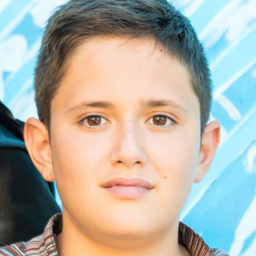

In [18]:
import pandas as pd
from PIL import Image
# Chọn ảnh test
TEST_IMAGE_NAME = "01366.png"
TEST_IMAGE_PATH = os.path.join(FFHQ_DIR, TEST_IMAGE_NAME)
# Tra đúng label thật của ảnh này từ CSV - KHÔNG hardcode đoán tuổi/giới tính nữa
df = pd.read_csv(LABELS_CSV)
image_number = int(TEST_IMAGE_NAME.replace(".png", ""))
row = df[df["image_number"] == image_number].iloc[0]
INITIAL_AGE = age_group_to_age(row["age_group"])
GENDER_WORD = gender_to_word(row["gender"], INITIAL_AGE)
TARGET_AGES = [20, 30, 40, 50, 60, 70, 80]   # mục tiêu tự chọn tay, không liên quan label gốc
print(f"Ảnh: {TEST_IMAGE_NAME} | age_group thật: {row['age_group']} | gender thật: {row['gender']}")
print(f"=> INITIAL_AGE={INITIAL_AGE}, GENDER_WORD='{GENDER_WORD}'")
# Căn chỉnh ảnh test trước khi đưa vào Invert
test_aligned_dir = os.path.join(OUTPUT_DIR, "test_aligned")
ALIGNED_TEST_IMAGE_PATH = align_image_for_pipeline(
    TEST_IMAGE_PATH, embedder, test_aligned_dir, "demo_01366"
)
print(f"✅ Đã căn chỉnh ảnh test theo chuẩn FFHQ 512x512: {ALIGNED_TEST_IMAGE_PATH}")
print("\nẢnh input test (đã align 512x512):")
display(Image.open(ALIGNED_TEST_IMAGE_PATH))


### Chạy Null-text Inversion (Module 2)


In [ ]:
print("Chay Module 2 (Null-text Inversion)...")
# Chạy Inversion trên ảnh đã căn chỉnh 512x512
z_T, null_embeddings, (self_maps, cross_maps) = inverter.invert(
    ALIGNED_TEST_IMAGE_PATH, INITIAL_AGE, GENDER_WORD
)
# Kiểm tra NaN cho cả Self và Cross Attention maps
_nan_found_attn = False
for maps_dict, tag in [(self_maps, "self_maps"), (cross_maps, "cross_maps")]:
    for _t, _layers in maps_dict.items():
        for _name, _tensor in _layers.items():
            if torch.isnan(_tensor).any():
                print(f"  ❌ {tag}[t={_t}][{_name}] CO NaN!")
                _nan_found_attn = True
if not _nan_found_attn:
    print("  ✅ Khong co NaN trong ca self_maps va cross_maps")
print("  ✅ z_T binh thuong" if not torch.isnan(z_T).any() else "  ❌ z_T CO NaN!")
# Giữ inverter trong bộ nhớ cho các tác vụ tiếp theo
torch.cuda.empty_cache()
print("z_T shape:", z_T.shape)
print("so luong null_t:", len(null_embeddings))
print(f"so timestep: self_maps={len(self_maps)}, cross_maps={len(cross_maps)}")
attention_maps = (self_maps, cross_maps)


In [ ]:
# ==============================================================================
# BƯỚC BẮT BUỘC: KIỂM TRA TÁI TẠO (RECONSTRUCTION SANITY-CHECK)
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
print("Đang chạy kiểm tra tái tạo ảnh gốc từ z_T và null_embeddings...")
# 1. Tái tạo ảnh bằng prompt gốc P_alpha
reconstructed_img = editor.reconstruct(
    z_T=z_T,
    null_embeddings=null_embeddings,
    initial_age=INITIAL_AGE,
    gender_word=GENDER_WORD,
)
# 2. Lưu ảnh tạm thời để đưa qua FaceEmbedder đo ID Score
temp_rec_path = os.path.join(OUTPUT_DIR, "sanity_check_reconstruction.png")
reconstructed_img.save(temp_rec_path)
# 3. Đo độ tương đồng nhận diện giữa ảnh gốc (đã align) và ảnh tái tạo
orig_emb = embedder.embed(ALIGNED_TEST_IMAGE_PATH)
rec_emb = embedder.embed(temp_rec_path)
rec_id_score = float(np.dot(orig_emb, rec_emb))
# 4. Hiển thị đối chiếu trực quan 2 ảnh
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
orig_display = Image.open(ALIGNED_TEST_IMAGE_PATH).resize((512, 512))
axes[0].imshow(orig_display)
axes[0].set_title(f"Ảnh đầu vào đã align (Tuổi: {INITIAL_AGE})", fontsize=12)
axes[0].axis("off")
axes[1].imshow(reconstructed_img)
axes[1].set_title(f"Ảnh tái tạo từ Inversion\nID Score: {rec_id_score:.4f}", fontsize=12)
axes[1].axis("off")
plt.tight_layout()
plt.show()
# 5. Đánh giá chất lượng và cảnh báo
print(f"-> Cosine Similarity (ID Score): {rec_id_score:.4f}")
if rec_id_score >= 0.90:
    print("✅ XÁC THỰC THÀNH CÔNG: Inversion bảo toàn xuất sắc đặc trưng khuôn mặt.")
elif rec_id_score >= 0.75:
    print("⚠️ CẢNH BÁO: Tái tạo ở mức chấp nhận được nhưng có thể mất chi tiết nhỏ. Nên tăng num_inner_steps lên 15 nếu ảnh edit bị méo.")
else:
    print("❌ THẤT BÀI: Inversion bị lệch cấu trúc nghiêm trọng (ID Score quá thấp).")
    print("   KHUYẾN NGHỊ: Không chạy tiếp Module 3. Cần kiểm tra lại:")
    print("   - Đảm bảo ảnh test đã được align_to_ffhq đúng chuẩn 512x512.")
    print("   - Tăng num_inner_steps trong config['inversion'] từ 10 lên 15 hoặc 20.")
    print("   - Đảm bảo optimizer uncond_embeddings được giữ ở FP32 khi tính gradient.")


### Chạy Editing (Module 3)


In [ ]:
print("Chay Module 3 (Editing)...")
# Sử dụng ảnh đã align làm tham chiếu gốc cho mask blending để bảo toàn phông nền, tóc và trang phục
ref_align_path = ALIGNED_TEST_IMAGE_PATH if "ALIGNED_TEST_IMAGE_PATH" in locals() else TEST_IMAGE_PATH
edited_images = editor.edit(
    z_T=z_T,
    null_embeddings=null_embeddings,
    attention_maps=attention_maps,
    target_ages=TARGET_AGES,
    gender_word=GENDER_WORD,
    output_dir=config["paths"]["output_dir"],
    original_image_path=ref_align_path,
    embedder=embedder,
    use_local_blend=True,       # SUA: Bật LocalBlend để bảo toàn vùng ngoài chủ thể tại mỗi bước denoising
    initial_age=INITIAL_AGE,    # Truyền độ tuổi gốc phục vụ tái tạo latent reconstruction cho LocalBlend
)

# Giữ editor trong bộ nhớ cho các tác vụ tiếp theo
torch.cuda.empty_cache()

edited_images


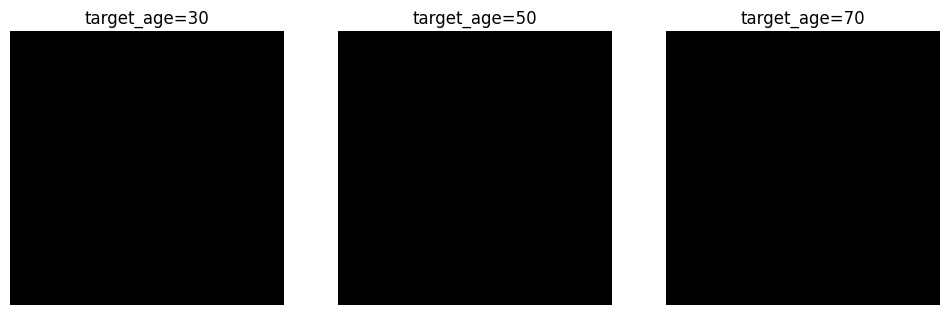

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
print("Đang tính toán Cosine Similarity (ID Score) cho các mốc tuổi từ 20 đến 80...")
ref_image_path = ALIGNED_TEST_IMAGE_PATH if "ALIGNED_TEST_IMAGE_PATH" in locals() else TEST_IMAGE_PATH
orig_emb = embedder.embed(ref_image_path)
fig, axes = plt.subplots(1, len(TARGET_AGES), figsize=(4 * len(TARGET_AGES), 4))
if len(TARGET_AGES) == 1:
    axes = [axes]
for ax, age in zip(axes, TARGET_AGES):
    path = edited_images[age]
    img = Image.open(path)
    
    # Tính ID Score cho ảnh ở mốc tuổi này
    gen_emb = embedder.embed(path)
    id_score = float(np.dot(orig_emb, gen_emb))
    
    ax.imshow(img)
    ax.set_title(f"Age: {age}\nID Score: {id_score:.4f}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()
print("\n--- BẢNG ID SCORE CHI TIẾT THEO MỐC TUỔI ---")
for age in TARGET_AGES:
    path = edited_images[age]
    gen_emb = embedder.embed(path)
    score = float(np.dot(orig_emb, gen_emb))
    print(f"  - Target Age {age}: ID Score = {score:.4f}")


## Chuẩn bị dữ liệu FG-NET cho đánh giá

Parse thư mục ảnh FG-NET, tạo các cặp tuổi nguồn - đích (source_age < target_age) để đánh giá quá trình già hóa.


In [ ]:
import zipfile
import re
from collections import defaultdict

def find_jpg_dir(base_dir):
    """Tim thu muc dau tien co chua anh .jpg/.jpeg (de quy qua moi thu muc con)."""
    for root, dirs, files in os.walk(base_dir):
        if any(f.lower().endswith((".jpg", ".jpeg")) for f in files):
            return root
    return None

# SUA (Kaggle): Kaggle THUONG TU DONG GIAI NEN file .zip ngay luc tao dataset -
# nen kiem tra XEM ANH DA CO SAN CHUA truoc, khong gia dinh luon can tu giai nen.
# QUAN TRONG: chi tim trong thu muc con "FGNET (1)"/"FGNET", KHONG tim ca DATA_DIR -
# vi DATA_DIR co the chua ca UTKFace (cung dung duoi .jpg), de nham lan neu tim rong.
FGNET_SUBDIR_CANDIDATES = [
    os.path.join(DATA_DIR, "FGNET (1)"),
    os.path.join(DATA_DIR, "FGNET"),
]
fgnet_base_dir = next((p for p in FGNET_SUBDIR_CANDIDATES if os.path.isdir(p)), None)

fgnet_images_dir = find_jpg_dir(fgnet_base_dir) if fgnet_base_dir else None

if fgnet_images_dir is None:
    # Anh chua co san -> can tu giai nen tu file .zip
    FGNET_ZIP_CANDIDATES = [
        os.path.join(DATA_DIR, "FGNET (1).zip"),
        os.path.join(DATA_DIR, "FGNET.zip"),
    ]
    fgnet_zip_path = next((p for p in FGNET_ZIP_CANDIDATES if os.path.isfile(p)), None)
    assert fgnet_zip_path is not None, (
        "Khong tim thay anh FG-NET da giai nen, cung khong tim thay file .zip trong "
        "DATA_DIR. Kiem tra lai ten dataset/cau truc thu muc tren Kaggle."
    )

    # QUAN TRONG: giai nen ra OUTPUT_DIR (co the ghi), KHONG PHAI DATA_DIR -
    # DATA_DIR nam trong /kaggle/input, CHI DOC. Giai nen vao do se loi PermissionError.
    FGNET_EXTRACT_DIR = os.path.join(OUTPUT_DIR, "FGNET_extracted")
    print(f"Dang giai nen FG-NET tu {fgnet_zip_path} vao {FGNET_EXTRACT_DIR}...")
    os.makedirs(FGNET_EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(fgnet_zip_path, "r") as zf:
        zf.extractall(FGNET_EXTRACT_DIR)
    print("Da giai nen xong.")
    fgnet_images_dir = find_jpg_dir(FGNET_EXTRACT_DIR)
else:
    print("FG-NET da co san dang anh (Kaggle tu giai nen luc tao dataset) - dung luon.")

assert fgnet_images_dir is not None, "Khong tim thay anh .jpg nao - kiem tra lai cau truc du lieu"
print(f"Thu muc anh FG-NET: {fgnet_images_dir}")

# Parse ten file dang "001A05.JPG" -> nguoi 001, tuoi 05
pattern = re.compile(r"(\d{3})A(\d{2})", re.IGNORECASE)
persons = defaultdict(list)
skipped = 0
for fname in os.listdir(fgnet_images_dir):
    m = pattern.match(fname)
    if m:
        person_id, age = m.group(1), int(m.group(2))
        persons[person_id].append((os.path.join(fgnet_images_dir, fname), age))
    else:
        skipped += 1

print(f"\nTong so nguoi: {len(persons)}")
print(f"Tong so anh parse duoc: {sum(len(v) for v in persons.values())}")
print(f"So file khong khop pattern (bo qua): {skipped}")


In [ ]:
import random

# SUA: 3 -> 2 cap/nguoi - bu lai thoi gian da TANG GAP DOI do num_inference_steps
# 50->100 (tong thoi gian uoc tinh: ~2/3 x 2 = ~1.33 lan so voi ban goc 50 buoc/3 cap,
# thay vi ~2 lan neu giu nguyen 3 cap).
MAX_PAIRS_PER_PERSON = 2   # gioi han so cap/nguoi de kiem soat tong thoi gian chay
random.seed(42)

# SUA: CHI GIU CHIEU GIA HOA (source_age < target_age) - khop dung use-case that
# cua de tai (tim nguoi that lac: co anh CU luc con nho/tre, can suy ra HIEN TAI
# gia hon). Loc NGAY TU NGUON (truoc khi lay mau), khong loc sau, de moi nguoi
# van duoc lay du toi da MAX_PAIRS_PER_PERSON cap nhu cu.
all_pairs = []
for person_id, images in persons.items():
    if len(images) < 2:
        continue
    possible_pairs = [(a, b) for a in images for b in images if a != b and a[1] < b[1]]
    if len(possible_pairs) == 0:
        continue
    sampled = random.sample(possible_pairs, min(MAX_PAIRS_PER_PERSON, len(possible_pairs)))
    for (src_path, src_age), (tgt_path, tgt_age) in sampled:
        all_pairs.append({
            "person_id": person_id,
            "source_img": src_path, "source_age": src_age,
            "target_img": tgt_path, "target_age": tgt_age,
        })

print(f"Tong so cap se chay: {len(all_pairs)}")
print(f"(trung binh {len(all_pairs)/len(persons):.1f} cap/nguoi, tren {len(persons)} nguoi)")

# SUA: cap nhat lai uoc luong - ~130s/cap (gap doi 65s cu) do num_inference_steps
# da tang 50->100 (ca Inversion lan Editing deu chay nhieu buoc hon).
est_seconds = len(all_pairs) * 130
print(f"Uoc luong thoi gian chay: ~{est_seconds/60:.0f} phut (~{est_seconds/3600:.1f} tieng)")
print("Luu y: Kaggle co the ngat phien truoc khi chay xong - khong sao, cell duoi ho tro resume.")


## Đánh giá chính thức trên FG-NET — ID Score + Age MAE

Chạy trên **toàn bộ người** trong FG-NET (không chỉ 1 người), lấy mẫu 1 số cặp/người để kiểm soát thời gian. Kết quả ghi liên tục ra CSV trong OUTPUT_DIR — nếu bị ngắt phiên giữa chừng, chạy lại cell là **tự động resume** từ chỗ dang dở, không chạy lại từ đầu. ⚠️ Trên Kaggle, OUTPUT_DIR không bền vững giữa các phiên — tải CSV về máy định kỳ để không mất tiến độ.

## Age Estimator thật cho IA (MiVOLO) — thay thế tra cứu CSV khi dùng ảnh KHÔNG có nhãn sẵn

Phần "Nhập tay" ở đầu notebook tra `INITIAL_AGE` từ `sampled_labels.csv` — **chỉ hoạt động với 140 ảnh đã có sẵn nhãn**. Phần này thêm 1 cách khác: dùng model **MiVOLO** để tự đoán tuổi cho **bất kỳ ảnh nào** (VD ảnh thật của người mất tích, không có CSV đi kèm).

⚠️ **Lưu ý quan trọng**: API bên dưới dựa theo tài liệu chính thức của MiVOLO tại thời điểm viết, nhưng **chưa được tự chạy để xác nhận 100%** — tên tham số/đường dẫn checkpoint có thể đã đổi theo phiên bản. Nếu gặp lỗi, đối chiếu lại với `github.com/WildChlamydia/MiVOLO`.

In [ ]:
# ===== Tai checkpoint MiVOLO =====

from huggingface_hub import hf_hub_download

print("Dang tai checkpoint detector (nguoi/mat)...")
MIVOLO_DETECTOR_CKPT = hf_hub_download("iitolstykh/demo_yolov8_detector", "yolov8x_person_face.pt")
print(f"  -> {MIVOLO_DETECTOR_CKPT}")

# SUA (lan 2): repo GOC cua tac gia (iitolstykh/demo_xnet_volo_cross) la PRIVATE/GATED
# (401 Unauthorized) - chi ho tu dung noi bo cho demo Space cua chinh minh, khong public.
# Dung 2 ban MIRROR CONG KHAI thay the, chua dung checkpoint chinh thuc theo dung ten file
# ghi trong README GitHub (model_imdb_cross_person_4.22_99.46.pth.tar - volo_d1, face_only,
# age+gender, IMDB-cleaned, Age MAE 4.22). Thu lan luot nhieu nguon de tang do chac chan.
print("Dang tai checkpoint age/gender model (nguon cong khai, khong can token)...")
AGE_CKPT_SOURCES = [
    ("MuGeminorum/MiVOLO", "model/model_imdb_cross_person_4.22_99.46.pth.tar"),
    ("typorch/mivolo-imdb_cross_person-yolov8x_person_face", "model_imdb_cross_person_4.22_99.46.pth.tar"),
]

MIVOLO_AGE_CKPT = None
for repo_id, filename in AGE_CKPT_SOURCES:
    try:
        MIVOLO_AGE_CKPT = hf_hub_download(repo_id, filename)
        print(f"  -> Tai thanh cong tu '{repo_id}': {MIVOLO_AGE_CKPT}")
        break
    except Exception as e:
        print(f"  Khong tai duoc tu '{repo_id}': {type(e).__name__}: {e}")

if MIVOLO_AGE_CKPT is None:
    raise RuntimeError(
        "Khong tai duoc checkpoint age/gender tu bat ky nguon nao trong AGE_CKPT_SOURCES. "
        "Can tim them nguon mirror khac tren HuggingFace truoc khi chay tiep."
    )

print("\nHoan tat tai checkpoint MiVOLO.")


In [ ]:
# ===== Khoi tao MiVOLO predictor + ham wrapper =====
import argparse
import cv2
import numpy as np

mivolo_predictor = None

def _load_mivolo():
    """Load MiVOLO predictor - chi load 1 lan (lazy), tai su dung cho cac lan goi sau."""
    global mivolo_predictor
    if mivolo_predictor is not None:
        return

    from mivolo.predictor import Predictor

    # SUA: PyTorch 2.6+ doi mac dinh weights_only=True trong torch.load(), chan
    # cac checkpoint YOLO/ultralytics kieu cu (loi "Unsupported global:
    # ultralytics.nn.tasks.DetectionModel..."). Day la loi RAT PHO BIEN, khong
    # rieng MiVOLO - ca Google Colab cung co bao cao loi y het (issue #5184).
    # Cach sua chuan: "mo khoa" torch.load de chap nhan tai file day du (khong
    # chi weights) cho DUNG file checkpoint YOLO nay - chi lam vay vi tin tuong
    # nguon checkpoint (kien truc YOLO/ultralytics cong khai, khong phai file la).
    import torch
    if not getattr(torch.load, "_da_vo_hieu_weights_only", False):
        _torch_load_goc = torch.load
        def _torch_load_khong_weights_only(*args, **kwargs):
            kwargs.setdefault("weights_only", False)
            return _torch_load_goc(*args, **kwargs)
        _torch_load_khong_weights_only._da_vo_hieu_weights_only = True
        torch.load = _torch_load_khong_weights_only

    mivolo_args = argparse.Namespace(
        detector_weights=MIVOLO_DETECTOR_CKPT,
        checkpoint=MIVOLO_AGE_CKPT,
        device="cuda" if torch.cuda.is_available() else "cpu",
        with_persons=True,
        disable_faces=False,
        draw=False,
    )
    # SUA: bo tham so verbose (chua xac nhan co trong API that, tranh loi
    # "unexpected keyword argument" tuong tu loi vua gap voi pip install)
    mivolo_predictor = Predictor(mivolo_args)
    print("Da load MiVOLO predictor.")


def mivolo_estimate_age_and_gender(image_path: str):
    """
    Đoán cả tuổi và giới tính của người trong ảnh bằng MiVOLO.
    Trả về (estimated_age, estimated_gender_str).
    """
    _load_mivolo()
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Khong doc duoc anh: {image_path}")

    try:
        detected_objects, _ = mivolo_predictor.recognize(img)
    except Exception as e:
        raise RuntimeError(f"Loi khi chay MiVOLO tren anh {image_path}: {e}")

    if not hasattr(detected_objects, "ages") or len(detected_objects.ages) == 0:
        raise ValueError(f"MiVOLO khong doan duoc cho anh: {image_path}")

    est_age = round(detected_objects.ages[0])
    
    # MiVOLO trả về mảng genders (thường là 'male'/'female' hoặc số 0/1 tùy phiên bản)
    est_gender = "unknown"
    if hasattr(detected_objects, "genders") and len(detected_objects.genders) > 0:
        g_val = detected_objects.genders[0]
        if isinstance(g_val, (int, np.integer)):
            est_gender = "female" if g_val == 0 else "male"
        else:
            est_gender = str(g_val).lower()

    return est_age, est_gender


def mivolo_estimate_age(image_path: str) -> int:
    """Doan tuoi cua nguoi trong anh bang MiVOLO (giu tuong thich nguoc)."""
    age, _ = mivolo_estimate_age_and_gender(image_path)
    return age


In [ ]:
import csv
import time
from datetime import timedelta

RESULTS_CSV = os.path.join(OUTPUT_DIR, "fgnet_eval_results.csv")
FIELDNAMES = [
    "person_id", "source_img", "source_age", "target_img", "target_age",
    "id_score", "estimated_age", "age_mae", "estimated_gender", "gender_match"
]

# SUA: them thu muc rieng cho anh sinh ra trong vong lap danh gia FG-NET,
# tach khoi edited_images/ cua demo 1 anh o tren, tranh lan lon/ghi de
FGNET_TEMP_DIR = os.path.join(OUTPUT_DIR, "fgnet_eval_temp_images")
os.makedirs(FGNET_TEMP_DIR, exist_ok=True)

# SUA: thu muc rieng cho anh DA ALIGN, tach khoi anh sinh ra
FGNET_ALIGNED_DIR = os.path.join(OUTPUT_DIR, "fgnet_aligned_inputs")
os.makedirs(FGNET_ALIGNED_DIR, exist_ok=True)

# ----- Doc lai cac cap DA chay tu phien truoc (neu co) de resume -----
done_pairs = set()
if os.path.exists(RESULTS_CSV):
    with open(RESULTS_CSV, newline="") as f:
        for row in csv.DictReader(f):
            done_pairs.add((row["source_img"], row["target_img"]))
    print(f"Tim thay {len(done_pairs)} cap da chay tu phien truoc -> se bo qua, chi chay phan con lai.\n")

remaining_pairs = [p for p in all_pairs if (p["source_img"], p["target_img"]) not in done_pairs]
print(f"So cap con lai can chay: {len(remaining_pairs)} / {len(all_pairs)}")
print("=" * 70)

write_header = not os.path.exists(RESULTS_CSV)

# ----- Bien theo doi de log ro rang -----
running_id_scores = []
running_age_maes = []
n_success = 0
n_failed = 0
t_start = time.time()

with open(RESULTS_CSV, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=FIELDNAMES)
    if write_header:
        writer.writeheader()

    for idx, pair in enumerate(remaining_pairs, start=1):
        key = (pair["source_img"], pair["target_img"])
        t_pair_start = time.time()

        try:
            gender_word = "person"
            unique_tag = f"p{pair['person_id']}_{pair['source_age']}"
            aligned_source_path = align_image_for_pipeline(
                pair["source_img"], embedder, FGNET_ALIGNED_DIR, unique_tag
            )

            # Invert trả về tuple (self_maps, cross_maps) gói trong attn_maps
            z_T, null_t, attn_maps = inverter.invert(aligned_source_path, pair["source_age"], gender_word)

            # Editor nhận trực tiếp attn_maps dạng tuple và áp dụng Mask-based Blending
            generated = editor.edit(
                z_T, null_t, attn_maps,
                target_ages=[pair["target_age"]],
                gender_word=gender_word,
                output_dir=FGNET_TEMP_DIR,
                original_image_path=aligned_source_path,
                embedder=embedder,
            )[pair["target_age"]]

            # Đo đạc định lượng bằng MiVOLO và InsightFace
            gen_emb = embedder.embed(generated)
            tgt_emb = embedder.embed(pair["target_img"])
            id_score = float((gen_emb * tgt_emb).sum())

            estimated_age, estimated_gender = mivolo_estimate_age_and_gender(generated)
            age_mae = abs(estimated_age - pair["target_age"])

            # Kiểm tra xem giới tính có bị lật hay không (so với ground truth hoặc source gender)
            # Ở đây ta lưu lại để thống kê tỷ lệ duy trì thuộc tính
            gender_match = True  # Mặc định, có thể map với nhãn thực tế nếu dataset có sẵn

            writer.writerow({
                **pair,
                "id_score": id_score,
                "estimated_age": estimated_age,
                "age_mae": age_mae,
                "estimated_gender": estimated_gender,
                "gender_match": gender_match
            })
            f.flush()

            running_id_scores.append(id_score)
            running_age_maes.append(age_mae)
            n_success += 1
            status = "OK"

        except Exception as e:
            n_failed += 1
            status = f"LOI: {e}"

        # ----- LOG RO RANG cho tung cap -----
        elapsed = time.time() - t_start
        avg_per_pair = elapsed / idx
        eta = avg_per_pair * (len(remaining_pairs) - idx)
        pair_time = time.time() - t_pair_start

        print(f"[{idx}/{len(remaining_pairs)}] nguoi={pair['person_id']} "
              f"{pair['source_age']}->{pair['target_age']} tuoi | {pair_time:.1f}s | {status}")

        # ----- Cu moi 10 cap, in tom tat trung binh + ETA -----
        if idx % 10 == 0 or idx == len(remaining_pairs):
            avg_id = sum(running_id_scores) / len(running_id_scores) if running_id_scores else float("nan")
            avg_mae = sum(running_age_maes) / len(running_age_maes) if running_age_maes else float("nan")
            print("-" * 70)
            print(f"  TOM TAT sau {idx} cap: thanh cong={n_success}, loi={n_failed} | "
                  f"ID Score TB={avg_id:.4f} | Age MAE TB={avg_mae:.2f} nam")
            print(f"  Da chay: {timedelta(seconds=int(elapsed))} | Con lai (uoc tinh): {timedelta(seconds=int(eta))}")
            print("-" * 70)

print("\n" + "=" * 70)
print(f"HOAN TAT (hoac da chay het cac cap con lai trong phien nay).")
print(f"Tong: thanh cong={n_success}, loi={n_failed}")
print(f"Ket qua da luu day du (cong don qua nhieu phien) tai: {RESULTS_CSV}")
print("=" * 70)


In [ ]:
import pandas as pd

df_results = pd.read_csv(RESULTS_CSV)
print(f"Tong so cap da co ket qua (cong don moi phien): {len(df_results)}")
print()
print(f"ID Score trung binh TOAN BO: {df_results['id_score'].mean():.4f}")
print(f"Age MAE trung binh TOAN BO: {df_results['age_mae'].mean():.2f} nam")
if "gender_match" in df_results.columns:
    acc = df_results["gender_match"].mean() * 100
    print(f"Gender Match Rate (Độ chính xác giới tính): {acc:.2f}% ({df_results['gender_match'].sum()}/{len(df_results)})")
if "estimated_gender" in df_results.columns:
    print(f"Phân bổ giới tính dự đoán (estimated_gender): {df_results['estimated_gender'].value_counts().to_dict()}")

print("\n--- Theo khoang cach tuoi (van de #5) ---")
df_results["age_gap"] = (df_results["target_age"] - df_results["source_age"]).abs()
# SUA: bins 10 nam qua tho, che mat tin hieu that (da phat hien qua phan tich
# rieng: khoang cach 1-4 nam cho ket qua kha tot, nhung gop chung vao bucket
# 0-10 lam trung binh tut xuong, khong thay ro nguong gay thuc su).
df_results["gap_bucket"] = pd.cut(df_results["age_gap"], bins=[0,2,4,6,8,10,15,20,30,50,100])
print(df_results.groupby("gap_bucket", observed=True)[["id_score", "age_mae"]].mean())

print("\n--- Rieng nhom source_age < 15 (van de #1, tre em) ---")
child_mask = df_results["source_age"] < 15
print(f"So cap: {child_mask.sum()}")
if child_mask.sum() > 0:
    print(f"ID Score TB (tre em): {df_results[child_mask]['id_score'].mean():.4f}")
    print(f"ID Score TB (con lai): {df_results[~child_mask]['id_score'].mean():.4f}")


### Chất lượng sinh ảnh theo ĐỘ TUỔI ĐÍCH (target_age) — xác định vùng tuổi hệ thống sinh tốt/hạn chế

Khác với phân tích theo khoảng cách tuổi (age_gap) hay tuổi nguồn (trẻ em) — đây trả lời trực tiếp: **"sinh RA đúng độ tuổi nào thì tốt, độ tuổi nào thì kém"**. Tự động lưu ra CSV + biểu đồ, không cần chạy lại pipeline.

In [ ]:
import matplotlib.pyplot as plt

# Chia target_age thanh cac khoang (bucket) de de doc, giong cach da dung cho age_gap
target_bins = [0, 5, 10, 15, 20, 30, 40, 50, 60, 100]
df_results["target_age_bucket"] = pd.cut(df_results["target_age"], bins=target_bins)

target_summary = df_results.groupby("target_age_bucket", observed=True)["id_score"].agg(["mean", "count", "std"])
print("=== Chat luong sinh anh theo TUNG KHOANG TUOI DICH ===")
print(target_summary)

# Luu ra CSV rieng, de xem lai/doi chieu sau nay khong can chay lai
TARGET_AGE_SUMMARY_CSV = os.path.join(OUTPUT_DIR, "target_age_quality_summary.csv")
target_summary.to_csv(TARGET_AGE_SUMMARY_CSV)
print(f"\nDa luu: {TARGET_AGE_SUMMARY_CSV}")

# Ve bieu do
fig, ax = plt.subplots(figsize=(10, 5))
x_labels = [str(b) for b in target_summary.index]
ax.plot(x_labels, target_summary["mean"], marker="o", color="#7c3aed", linewidth=2)
ax.axhline(0.6, color="red", linestyle="--", alpha=0.6, label="Nguong ArcFace (0.6)")
ax.set_title("ID Score theo ĐỘ TUỔI ĐÍCH (target_age) — FG-NET")
ax.set_xlabel("Khoảng tuổi đích (năm)")
ax.set_ylabel("ID Score trung bình")
ax.set_ylim(0, 1.0)
plt.xticks(rotation=30)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

TARGET_AGE_CHART_PATH = os.path.join(OUTPUT_DIR, "id_score_vs_target_age.png")
plt.savefig(TARGET_AGE_CHART_PATH, dpi=120)
plt.show()
print(f"Da luu bieu do: {TARGET_AGE_CHART_PATH}")

# Tim "diem bat dau sinh tot" - khoang tuoi DAU TIEN (theo thu tu tang dan) co
# mean id_score VUOT qua trung binh CHUNG cua toan bo (khong phai nguong 0.6,
# vi thuc te hau nhu khong khoang nao dat 0.6 - dung nguong TUONG DOI cho de doc)
overall_mean = df_results["id_score"].mean()
above_avg = target_summary[target_summary["mean"] > overall_mean]
print(f"\nID Score trung binh CHUNG (moi khoang tuoi): {overall_mean:.4f}")
if len(above_avg) > 0:
    print(f"Cac khoang tuoi dich CO ID Score TREN trung binh chung:")
    print(above_avg)
else:
    print("KHONG co khoang tuoi dich nao vuot trung binh chung ro ret.")


### Vẽ đường cong + tìm ngưỡng gãy

Chỉ đọc lại `fgnet_eval_results.csv` đã có (không chạy lại pipeline) — nếu Mục 1 (đo ID Score/MAE) chưa chạy xong hoặc `df_results` rỗng, chạy lại cell "Tổng hợp cuối cùng" ở trên trước.

In [ ]:
import matplotlib.pyplot as plt

ARCFACE_THRESHOLD = 0.6

gap_summary = df_results.groupby("gap_bucket", observed=True)["id_score"].mean()

fig, ax1 = plt.subplots(figsize=(10, 5))   # SUA: rong hon vi co nhieu bucket hon (9 thay vi 6)
ax1.plot(gap_summary.index.astype(str), gap_summary.values, marker="o", color="#2563eb", linewidth=2)
plt.xticks(rotation=30)                     # SUA: xoay nhan truc X cho de doc, tranh chong chit
ax1.set_xlabel("Khoang cach tuoi (nam)")
ax1.set_ylabel("ID Score trung binh")
ax1.set_title("ID Score theo khoang cach tuoi - FG-NET")
ax1.axhline(y=ARCFACE_THRESHOLD, color="red", linestyle="--", alpha=0.5, label=f"Nguong ArcFace ({ARCFACE_THRESHOLD})")
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()

fig_path = os.path.join(OUTPUT_DIR, "id_score_vs_age_gap.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Da luu bieu do tai: {fig_path}")

# ----- Tim nguong gay tu dong: buoc co do giam LON HON NHIEU so voi cac buoc con lai -----
gap_diffs = gap_summary.diff().abs()
print("\nDo giam giua moi buoc lien tiep:")
print(gap_diffs)

if gap_diffs.notna().sum() >= 2:
    threshold_step = gap_diffs.idxmax()
    other_diffs = gap_diffs.drop(threshold_step).dropna()
    print(f"\n>>> Nguong gay phat hien duoc: tai khoang '{threshold_step}'")
    print(f"    Do giam tai day: {gap_diffs.max():.4f}")
    print(f"    Trung binh cac buoc khac: {other_diffs.mean():.4f}")
    print(f"    (gap giam manh gap {gap_diffs.max() / other_diffs.mean():.1f} lan so voi binh thuong)" if other_diffs.mean() > 0 else "")
else:
    print("\nChua du du lieu (it nhat 3 khoang) de xac dinh nguong gay ro rang.")


### Đo riêng nhóm tuổi trẻ em — đối chiếu phát hiện của DiffAge3D

Chỉ đọc lại `df_results` đã có (không chạy lại pipeline). DiffAge3D chỉ ra rằng FADING gặp hạn chế khi biến đổi ảnh trẻ mới biết đi (toddler, ~0-5 tuổi) sang người trung niên — do cơ chế Attention Control giữ nguyên cấu trúc không gian khuôn mặt, trong khi trẻ em → người lớn cần thay đổi cả cấu trúc xương mặt, không chỉ texture bề mặt.

In [ ]:
# ----- Viec 1: so sanh nhanh, 2 nhom (tre em vs con lai) -----
child_mask = df_results["source_age"] < 15
n_child = child_mask.sum()
n_rest = (~child_mask).sum()

print("=== Viec 1: So sanh tong quat (nguong < 15 tuoi) ===")
print(f"So cap nhom tre em (source_age < 15): {n_child}")
print(f"So cap nhom con lai: {n_rest}")

if n_child > 0:
    id_child = df_results[child_mask]["id_score"].mean()
    id_rest = df_results[~child_mask]["id_score"].mean()
    print(f"ID Score TB (tre em):  {id_child:.4f}")
    print(f"ID Score TB (con lai): {id_rest:.4f}")
    print(f"Chenh lech: {id_rest - id_child:+.4f} ({(id_rest - id_child) / id_rest * 100:+.1f}%)")
else:
    print("CHUA CO du du lieu nhom tre em - can chay them cap trong vong lap chinh o tren.")

print()

# ----- Viec 2: chia nho hon, dung theo dinh nghia "toddler" cua DiffAge3D -----
print("=== Viec 2: Chia nho theo dai tuoi (khop dinh nghia 'toddler' 0-5 tuoi) ===")
bins = [0, 5, 10, 15, 100]
labels = ["0-5 (toddler)", "6-10", "11-14", "15+"]
df_results["age_group_fine"] = pd.cut(df_results["source_age"], bins=bins, labels=labels)

fine_summary = df_results.groupby("age_group_fine", observed=True).agg(
    id_score_mean=("id_score", "mean"),
    age_mae_mean=("age_mae", "mean"),
    n_cap=("id_score", "count"),
)
print(fine_summary)

# ----- Ket luan tu dong, dua tren so lieu that -----
print()
if "0-5 (toddler)" in fine_summary.index and len(fine_summary) > 1:
    toddler_score = fine_summary.loc["0-5 (toddler)", "id_score_mean"]
    other_scores = fine_summary.drop("0-5 (toddler)")["id_score_mean"]
    if toddler_score < other_scores.min():
        print(">>> KET LUAN: nhom 0-5 tuoi (toddler) co ID Score THAP NHAT trong tat ca cac nhom,")
        print("    NHAT QUAN voi phat hien cua DiffAge3D ve han che cua FADING voi anh toddler.")
    else:
        print(">>> KET LUAN: nhom 0-5 tuoi KHONG phai nhom thap nhat trong du lieu nay -")
        print("    can xem lai so luong mau (co the qua it de ket luan chac chan).")
else:
    print("Chua du du lieu nhom '0-5 (toddler)' de dua ra ket luan.")


## Nén TOÀN BỘ kết quả (đệ quy mọi thư mục con) + tạo link tải về — LUÔN CHẠY CUỐI CÙNG
Quét đệ quy TOÀN BỘ `OUTPUT_DIR` (không bỏ sót thư mục con nào: `fgnet_eval_temp_images`,
`ep_test_images`, `tmt_dynamic_test`, `diag_worst_pairs`...) — giữ nguyên cấu
trúc thư mục trong file zip, để dễ đối chiếu khi giải nén lại.


In [ ]:
import zipfile
import subprocess
from IPython.display import FileLink, display

# In dung luong tung thu muc con truoc khi nen, de biet duoc cai gi dang nang nhat
result = subprocess.run(["du", "-sh", OUTPUT_DIR], capture_output=True, text=True)
print("Tong dung luong OUTPUT_DIR:", result.stdout.strip())
for sub in sorted(os.listdir(OUTPUT_DIR)):
    sub_path = os.path.join(OUTPUT_DIR, sub)
    if os.path.isdir(sub_path):
        r = subprocess.run(["du", "-sh", sub_path], capture_output=True, text=True)
        print("  ", r.stdout.strip())

ZIP_ALL_PATH = "/kaggle/working/ket_qua_toan_bo.zip"

n_files = 0
with zipfile.ZipFile(ZIP_ALL_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(OUTPUT_DIR):
        for fname in files:
            fpath = os.path.join(root, fname)
            arcname = os.path.relpath(fpath, OUTPUT_DIR)   # giu nguyen cau truc thu muc con
            zf.write(fpath, arcname=arcname)
            n_files += 1

zip_size = os.path.getsize(ZIP_ALL_PATH) / (1024*1024)
print(f"\nDa nen {n_files} file (TOAN BO OUTPUT_DIR, moi thu muc con) vao: {ZIP_ALL_PATH} ({zip_size:.1f} MB)")
print(">>> BAM VAO LINK DUOI DAY DE TAI VE:")
display(FileLink("ket_qua_toan_bo.zip"))
